# Demo 5: Comparing Pose Modules to Manual Scoring Data

*Written and last updated July 19, 2025 by Sedona Ewbank, snewbank@stanford.edu*

The purpose of this demo is to demonstrate how to compare our pose modules to describable behavior classes using a manual scoring dataset for comparison.

In [1]:
import os
import sys
import importlib

#This block only important for running as script
#script_dir = os.path.dirname(os.path.abspath(__file__))
mariposa_dir = "/Users/snewbank/PycharmProjects/MARIPoSA"
utils_dir = os.path.join(mariposa_dir, 'utils')
sys.path.append(utils_dir)
sys.path.append(mariposa_dir)

#import utils
from utils import metadata, analyze, plot, simulate

importlib.reload(metadata)
importlib.reload(analyze)
importlib.reload(plot)
importlib.reload(simulate)

<module 'utils.simulate' from '/Users/snewbank/PycharmProjects/MARIPoSA/utils/simulate.py'>

In [2]:
demo_dir="/Users/snewbank/Behavior/MARIPoSA_demo_data/"
config=metadata.load_project(demo_dir+"250719_test/config_PS.yaml")
save=True
save_path = demo_dir+"demo_figures/"
if not os.path.exists(save_path):
    os.makedirs(save_path)

## 5.1: Remapping pose modules to grouped classes

It is simple to remap pose modules to groups however you like - perhaps from visual inspection or some other approach to grouping. To do so, you just reset the "remappings" key from the config (either in python or directly in the config file). Then, when you create a labels_df object, use analyze.combine_pose_modules to remap modules to their assigned remapping class.

sal  \
      2023-06-15_21-28-12_bf04_salivDLC_resnet101_DevRats2Jul21shuffle1_500000   
0                                                      0                         
1                                                      0                         
2                                                      0                         
3                                                      0                         
4                                                      0                         
...                                                  ...                         
35995                                                 17                         
35996                                                 17                         
35997                                                 17                         
35998                                                 17                         
35999                                                 17                         

                                                                                \
      2023-06-15_22-01-50_bf03_salivDLC_resnet101_DevRats2Jul21shuffle1_500000   
0                                                      9                         
1                                                      9                         
2                                                      9                         
3                                                      9                         
4                                                      9                         
...                                                  ...                         
35995                                                 27                         
35996                                                 27                         
35997                                                 27                         
35998                                                 27                         
35999                                                 27                         

                                                                                \
      2023-06-20_15-41-01_bm03_salivDLC_resnet101_DevRats2Jul21shuffle1_500000   
0                                                      0                         
1                                                      0                         
2                                                      0                         
3                                                      0                         
4                                                      0                         
...                                                  ...                         
35995                                                 13                         
35996                                                 13                         
35997                                                 13                         
35998                                                 13                         
35999                                                 13                         

                                                                                \
      2023-06-20_16-13-48_bm04_salivDLC_resnet101_DevRats2Jul21shuffle1_500000   
0                                                     10                         
1                                                     10                         
2                                                     10                         
3                                                     10                         
4                                                     10                         
...                                                  ...                         
35995                                                 13                         
35996                                                 13                         
35997                                                 

Applying 2 remapping rules from config.
1 of 2: Remapping [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14] to modules_0-14


2 of 2: Remapping [15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29] to modules_15-29


sal  \
      2023-06-15_21-28-12_bf04_salivDLC_resnet101_DevRats2Jul21shuffle1_500000   
0                                           modules_0-14                         
1                                           modules_0-14                         
2                                           modules_0-14                         
3                                           modules_0-14                         
4                                           modules_0-14                         
...                                                  ...                         
35995                                      modules_15-29                         
35996                                      modules_15-29                         
35997                                      modules_15-29                         
35998                                      modules_15-29                         
35999                                      modules_15-29                         

                                                                                \
      2023-06-15_22-01-50_bf03_salivDLC_resnet101_DevRats2Jul21shuffle1_500000   
0                                           modules_0-14                         
1                                           modules_0-14                         
2                                           modules_0-14                         
3                                           modules_0-14                         
4                                           modules_0-14                         
...                                                  ...                         
35995                                      modules_15-29                         
35996                                      modules_15-29                         
35997                                      modules_15-29                         
35998                                      modules_15-29                         
35999                                      modules_15-29                         

                                                                                \
      2023-06-20_15-41-01_bm03_salivDLC_resnet101_DevRats2Jul21shuffle1_500000   
0                                           modules_0-14                         
1                                           modules_0-14                         
2                                           modules_0-14                         
3                                           modules_0-14                         
4                                           modules_0-14                         
...                                                  ...                         
35995                                       modules_0-14                         
35996                                       modules_0-14                         
35997                                       modules_0-14                         
35998                                       modules_0-14                         
35999                                       modules_0-14                         

                                                                                \
      2023-06-20_16-13-48_bm04_salivDLC_resnet101_DevRats2Jul21shuffle1_500000   
0                                           modules_0-14                         
1                                           modules_0-14                         
2                                           modules_0-14                         
3                                           modules_0-14                         
4                                           modules_0-14                         
...                                                  ...                         
35995                                       modules_0-14                         
35996                                       modules_0-14                         
35997                                       modules_0-

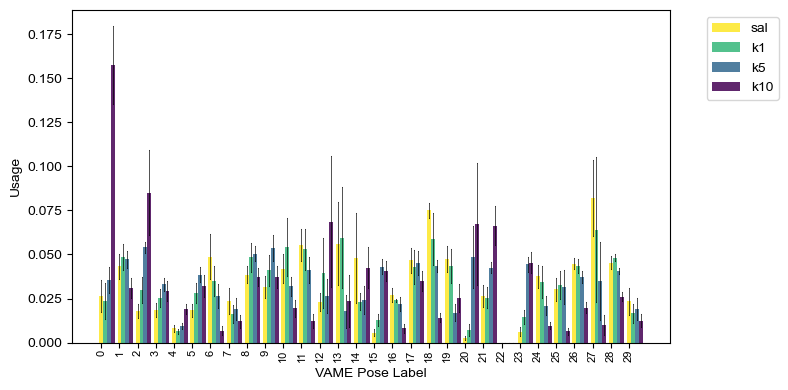

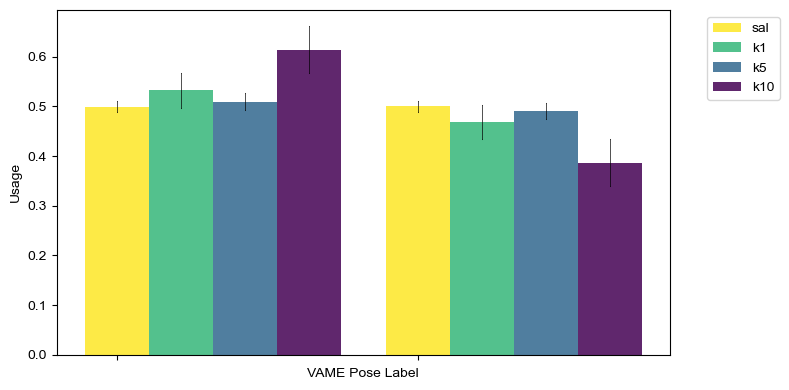

In [3]:
config["remappings"] = [[[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14],"modules_0-14"],
                        [[15,16,17,18,19,20,21,22,23,24,25,26,27,28,29],"modules_15-29"]]

labels_df = analyze.get_module_labels(config,0,1200,subgroups=["sal","k1","k5","k10"])
display(labels_df)
module_usage = analyze.get_module_usage(config,labels_df)
fig = plot.plot_module_usage(config,
                             module_usage,
                             style="bar_error",
                             figW=8,
                             figH=4,
                             cmap="viridis_r")

labels_df_remap = analyze.combine_pose_modules(config,labels_df)
display(labels_df_remap)
module_usage = analyze.get_module_usage(config,labels_df,modules_altered=True) # you must set modules_altered = True to get the correct behavior if you have altered the modules, i.e. by remapping to manual scoring class
fig = plot.plot_module_usage(config,
                             module_usage,
                             style="bar_error",
                             figW=8,
                             figH=4,
                             cmap="viridis_r")
if save:
    fig.savefig(save_path+"demo5-1_boris_remapped_usage.png",dpi=300)

## 5.2: Incorporating manual scoring data from BORIS to remap modules

The approach used in MARIPoSA for identifying the behaviors represented by pose modules is to compare to manual scoring data. We have found it is simplest to use manual scoring data incorporated from BORIS and exported in the frame rate of the video as one-hot encoded csv. We then need to set the BORIS csv directory path and the pairings of videos and their corresponding project file within the config.

In [4]:
print("Before editing (default):")
print(config['boris_directory'])
print(config['boris_to_pose_pairings'])

config['boris_directory'] = demo_dir + "PS-TEST-25-03-31-ManualScoring/"
config['boris_to_pose_pairings'] = [
    ['BINARY_2023-05-09_17-41-11_bf01_nal10k10.csv','2023-05-09_17-41-11_bf01_nal10k10DLC_resnet101_DevRats2Jul21shuffle1_500000'],
    ['BINARY_13-39-15_bm01_k25.csv','2023-05-30_13-39-15_bm01_k25DLC_resnet101_DevRats2Jul21shuffle1_500000'],
    ['BINARY_1_2023-05-31_12-02-23_bf02_coc.csv','2023-05-31_12-02-23_bf02_cocDLC_resnet101_DevRats2Jul21shuffle1_500000'],
    ['BINARY_2023-06-15_19-15-24_bm04_nalket.csv','2023-06-15_19-15-24_bm04_nalketDLC_resnet101_DevRats2Jul21shuffle1_500000'],
    ['BINARY_2023-06-15_17-16-18_bm01_k5iv.csv','2023-06-15_17-16-18_bm01_k5ivDLC_resnet101_DevRats2Jul21shuffle1_500000'],
    ['BINARY_2023-06-09_18-18-49_bm02_k25.csv','2023-06-09_18-18-49_bm02_k25DLC_resnet101_DevRats2Jul21shuffle1_500000'],
    ['BINARY_2023-07-08_15-13-11_bf03_k25.csv','2023-07-08_15-13-11_bf03_k25DLC_resnet101_DevRats2Jul21shuffle1_500000'],
    ['BINARY_bf01_k5.csv','2023-06-20_16-46-29_bf01_k5DLC_resnet101_DevRats2Jul21shuffle1_500000']
]
print("After editing:")
print(config['boris_directory'])
print(config['boris_to_pose_pairings'])

Before editing (default):
None
[[None, None], [None, None], [None, None]]
After editing:
/Users/snewbank/Behavior/MARIPoSA_demo_data/PS-TEST-25-03-31-ManualScoring/
[['BINARY_2023-05-09_17-41-11_bf01_nal10k10.csv', '2023-05-09_17-41-11_bf01_nal10k10DLC_resnet101_DevRats2Jul21shuffle1_500000'], ['BINARY_13-39-15_bm01_k25.csv', '2023-05-30_13-39-15_bm01_k25DLC_resnet101_DevRats2Jul21shuffle1_500000'], ['BINARY_1_2023-05-31_12-02-23_bf02_coc.csv', '2023-05-31_12-02-23_bf02_cocDLC_resnet101_DevRats2Jul21shuffle1_500000'], ['BINARY_2023-06-15_19-15-24_bm04_nalket.csv', '2023-06-15_19-15-24_bm04_nalketDLC_resnet101_DevRats2Jul21shuffle1_500000'], ['BINARY_2023-06-15_17-16-18_bm01_k5iv.csv', '2023-06-15_17-16-18_bm01_k5ivDLC_resnet101_DevRats2Jul21shuffle1_500000'], ['BINARY_2023-06-09_18-18-49_bm02_k25.csv', '2023-06-09_18-18-49_bm02_k25DLC_resnet101_DevRats2Jul21shuffle1_500000'], ['BINARY_2023-07-08_15-13-11_bf03_k25.csv', '2023-07-08_15-13-11_bf03_k25DLC_resnet101_DevRats2Jul21shuffle1_50

Once we have done that, we can then look at the overlap between manually scored behaviors and pose modules:

done with ['BINARY_2023-05-09_17-41-11_bf01_nal10k10.csv', '2023-05-09_17-41-11_bf01_nal10k10DLC_resnet101_DevRats2Jul21shuffle1_500000']
done with ['BINARY_13-39-15_bm01_k25.csv', '2023-05-30_13-39-15_bm01_k25DLC_resnet101_DevRats2Jul21shuffle1_500000']


done with ['BINARY_1_2023-05-31_12-02-23_bf02_coc.csv', '2023-05-31_12-02-23_bf02_cocDLC_resnet101_DevRats2Jul21shuffle1_500000']
done with ['BINARY_2023-06-15_19-15-24_bm04_nalket.csv', '2023-06-15_19-15-24_bm04_nalketDLC_resnet101_DevRats2Jul21shuffle1_500000']


done with ['BINARY_2023-06-15_17-16-18_bm01_k5iv.csv', '2023-06-15_17-16-18_bm01_k5ivDLC_resnet101_DevRats2Jul21shuffle1_500000']
done with ['BINARY_2023-06-09_18-18-49_bm02_k25.csv', '2023-06-09_18-18-49_bm02_k25DLC_resnet101_DevRats2Jul21shuffle1_500000']


done with ['BINARY_2023-07-08_15-13-11_bf03_k25.csv', '2023-07-08_15-13-11_bf03_k25DLC_resnet101_DevRats2Jul21shuffle1_500000']
done with ['BINARY_bf01_k5.csv', '2023-06-20_16-46-29_bf01_k5DLC_resnet101_DevRats2Jul21shuffle1_500000']
VAME modules map onto scored behaviors with 'loss' of 0.47849370930131485


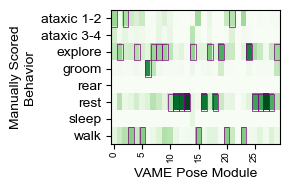

In [5]:
BORIS_to_pose_mat, BORIS_to_pose_mat_normalized, loss = analyze.BORIS_to_pose(config)
fig = plot.BORIS_to_pose_matrix_plot(config, BORIS_to_pose_mat_normalized, figW=3, figH=2, cmap="Greens",outline_top_match=True)
if save:
    fig.savefig(save_path+"demo5-2_boris_to_pose_matrix.png",dpi=500)

Once you have the manually scored class for each module, you can remap them to compare usage of grouped modules.

sal  \
      2023-06-15_21-28-12_bf04_salivDLC_resnet101_DevRats2Jul21shuffle1_500000   
0                                                      0                         
1                                                      0                         
2                                                      0                         
3                                                      0                         
4                                                      0                         
...                                                  ...                         
35995                                                 17                         
35996                                                 17                         
35997                                                 17                         
35998                                                 17                         
35999                                                 17                         

                                                                                \
      2023-06-15_22-01-50_bf03_salivDLC_resnet101_DevRats2Jul21shuffle1_500000   
0                                                      9                         
1                                                      9                         
2                                                      9                         
3                                                      9                         
4                                                      9                         
...                                                  ...                         
35995                                                 27                         
35996                                                 27                         
35997                                                 27                         
35998                                                 27                         
35999                                                 27                         

                                                                                \
      2023-06-20_15-41-01_bm03_salivDLC_resnet101_DevRats2Jul21shuffle1_500000   
0                                                      0                         
1                                                      0                         
2                                                      0                         
3                                                      0                         
4                                                      0                         
...                                                  ...                         
35995                                                 13                         
35996                                                 13                         
35997                                                 13                         
35998                                                 13                         
35999                                                 13                         

                                                                                \
      2023-06-20_16-13-48_bm04_salivDLC_resnet101_DevRats2Jul21shuffle1_500000   
0                                                     10                         
1                                                     10                         
2                                                     10                         
3                                                     10                         
4                                                     10                         
...                                                  ...                         
35995                                                 13                         
35996                                                 13                         
35997                                                 

done with ['BINARY_2023-05-09_17-41-11_bf01_nal10k10.csv', '2023-05-09_17-41-11_bf01_nal10k10DLC_resnet101_DevRats2Jul21shuffle1_500000']
done with ['BINARY_13-39-15_bm01_k25.csv', '2023-05-30_13-39-15_bm01_k25DLC_resnet101_DevRats2Jul21shuffle1_500000']
done with ['BINARY_1_2023-05-31_12-02-23_bf02_coc.csv', '2023-05-31_12-02-23_bf02_cocDLC_resnet101_DevRats2Jul21shuffle1_500000']
done with ['BINARY_2023-06-15_19-15-24_bm04_nalket.csv', '2023-06-15_19-15-24_bm04_nalketDLC_resnet101_DevRats2Jul21shuffle1_500000']


done with ['BINARY_2023-06-15_17-16-18_bm01_k5iv.csv', '2023-06-15_17-16-18_bm01_k5ivDLC_resnet101_DevRats2Jul21shuffle1_500000']
done with ['BINARY_2023-06-09_18-18-49_bm02_k25.csv', '2023-06-09_18-18-49_bm02_k25DLC_resnet101_DevRats2Jul21shuffle1_500000']
done with ['BINARY_2023-07-08_15-13-11_bf03_k25.csv', '2023-07-08_15-13-11_bf03_k25DLC_resnet101_DevRats2Jul21shuffle1_500000']
done with ['BINARY_bf01_k5.csv', '2023-06-20_16-46-29_bf01_k5DLC_resnet101_DevRats2Jul21shuffle1_500000']
VAME modules map onto scored behaviors with 'loss' of 0.47849370930131485
Applying 30 remapping rules from config.
1 of 30: Remapping [0] to ataxic 1-2


2 of 30: Remapping [1] to explore


3 of 30: Remapping [2] to ataxic 1-2


...

27 of 30: Remapping [26] to rest


28 of 30: Remapping [27] to rest


29 of 30: Remapping [28] to rest


30 of 30: Remapping [29] to explore


sal  \
      2023-06-15_21-28-12_bf04_salivDLC_resnet101_DevRats2Jul21shuffle1_500000   
0                                             ataxic 1-2                         
1                                             ataxic 1-2                         
2                                             ataxic 1-2                         
3                                             ataxic 1-2                         
4                                             ataxic 1-2                         
...                                                  ...                         
35995                                            explore                         
35996                                            explore                         
35997                                            explore                         
35998                                            explore                         
35999                                            explore                         

                                                                                \
      2023-06-15_22-01-50_bf03_salivDLC_resnet101_DevRats2Jul21shuffle1_500000   
0                                                explore                         
1                                                explore                         
2                                                explore                         
3                                                explore                         
4                                                explore                         
...                                                  ...                         
35995                                               rest                         
35996                                               rest                         
35997                                               rest                         
35998                                               rest                         
35999                                               rest                         

                                                                                \
      2023-06-20_15-41-01_bm03_salivDLC_resnet101_DevRats2Jul21shuffle1_500000   
0                                             ataxic 1-2                         
1                                             ataxic 1-2                         
2                                             ataxic 1-2                         
3                                             ataxic 1-2                         
4                                             ataxic 1-2                         
...                                                  ...                         
35995                                               rest                         
35996                                               rest                         
35997                                               rest                         
35998                                               rest                         
35999                                               rest                         

                                                                                \
      2023-06-20_16-13-48_bm04_salivDLC_resnet101_DevRats2Jul21shuffle1_500000   
0                                                   rest                         
1                                                   rest                         
2                                                   rest                         
3                                                   rest                         
4                                                   rest                         
...                                                  ...                         
35995                                               rest                         
35996                                               rest                         
35997                                               re

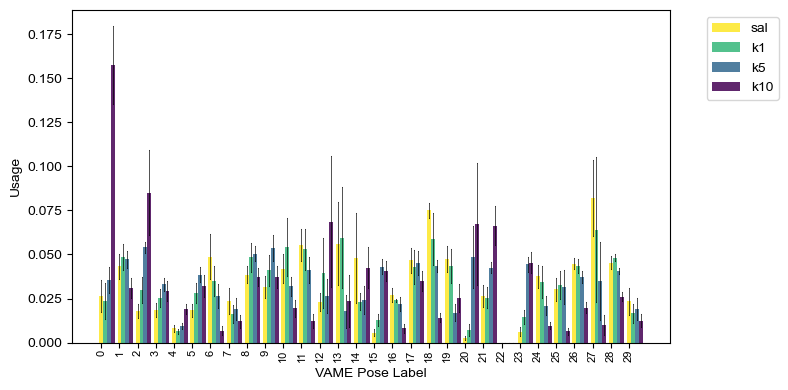

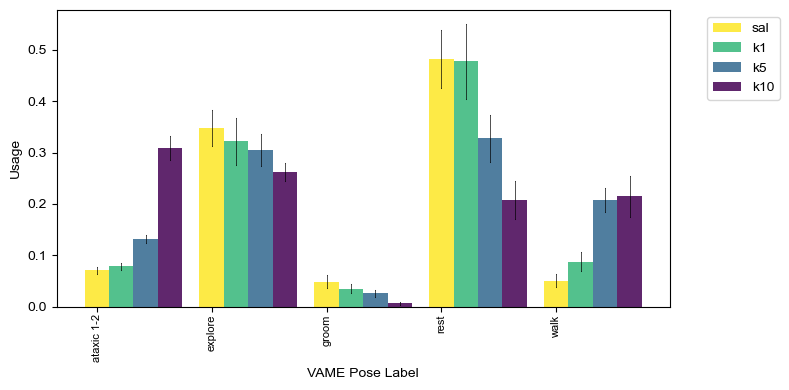

In [6]:
# First, we'll do our dose-response with modules not grouped:
labels_df = analyze.get_module_labels(config,0,1200,subgroups=["sal","k1","k5","k10"])
display(labels_df)
module_usage = analyze.get_module_usage(config,labels_df)
fig = plot.plot_module_usage(config,
                             module_usage,
                             style="bar_error",
                             figW=8,
                             figH=4,
                             cmap="viridis_r")

# Then we can look at our dose-response data with modules remapped to their manual score overlap
BORIS_to_pose_mat, BORIS_to_pose_mat_normalized, loss = analyze.BORIS_to_pose(config)
labels_df_remap = analyze.make_remappings_from_BORIS(config,labels_df = labels_df, BORIS_to_pose_mat = BORIS_to_pose_mat)
display(labels_df_remap)

module_usage = analyze.get_module_usage(config,labels_df,modules_altered=True) # you must set modules_altered = True to get the correct behavior if you have altered the modules, i.e. by remapping to manual scoring class
fig = plot.plot_module_usage(config,
                             module_usage,
                             style="bar_error",
                             figW=8,
                             figH=4,
                             cmap="viridis_r")
if save:
    fig.savefig(save_path+"demo5-3_boris_remapped_usage.png",dpi=300)